
# SHA Witness Eye
## See what SHA sees

Keep these separate:

$$
\text{input} \neq \text{SHA} \neq \text{hash}
$$

Treat the digest as a **witness**.

Then the real object is:

$$
\boxed{
\text{witness\_eye}(M)=\{E_r(M)\}_{r=0}^{63}
}
$$

This notebook exposes, round by round, what SHA actually reads at the seam:
- `W`
- `Sigma1(e)`
- `Ch(e,f,g)`
- `K`
- `Sigma0(a)`
- `Maj(a,b,c)`
- `T1`
- `T2`
- carry geometry
- xor weight
- Sziklai differential
- delta vs NOP backbone


In [1]:

from pathlib import Path
import hashlib
from functools import reduce
import operator

import pandas as pd
import matplotlib.pyplot as plt

MASK32 = 0xffffffff
OUTDIR = Path("sha_witness_eye_outputs")
OUTDIR.mkdir(exist_ok=True)


In [2]:

H0 = [
    0x6A09E667, 0xBB67AE85, 0x3C6EF372, 0xA54FF53A,
    0x510E527F, 0x9B05688C, 0x1F83D9AB, 0x5BE0CD19,
]

K = [
    0x428a2f98,0x71374491,0xb5c0fbcf,0xe9b5dba5,0x3956c25b,0x59f111f1,0x923f82a4,0xab1c5ed5,
    0xd807aa98,0x12835b01,0x243185be,0x550c7dc3,0x72be5d74,0x80deb1fe,0x9bdc06a7,0xc19bf174,
    0xe49b69c1,0xefbe4786,0x0fc19dc6,0x240ca1cc,0x2de92c6f,0x4a7484aa,0x5cb0a9dc,0x76f988da,
    0x983e5152,0xa831c66d,0xb00327c8,0xbf597fc7,0xc6e00bf3,0xd5a79147,0x06ca6351,0x14292967,
    0x27b70a85,0x2e1b2138,0x4d2c6dfc,0x53380d13,0x650a7354,0x766a0abb,0x81c2c92e,0x92722c85,
    0xa2bfe8a1,0xa81a664b,0xc24b8b70,0xc76c51a3,0xd192e819,0xd6990624,0xf40e3585,0x106aa070,
    0x19a4c116,0x1e376c08,0x2748774c,0x34b0bcb5,0x391c0cb3,0x4ed8aa4a,0x5b9cca4f,0x682e6ff3,
    0x748f82ee,0x78a5636f,0x84c87814,0x8cc70208,0x90befffa,0xa4506ceb,0xbef9a3f7,0xc67178f2,
]

def rotr(x: int, n: int) -> int:
    return ((x >> n) | ((x << (32 - n)) & MASK32)) & MASK32

def shr(x: int, n: int) -> int:
    return (x >> n) & MASK32

def Sigma0(x: int) -> int:
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def Sigma1(x: int) -> int:
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def sigma0(x: int) -> int:
    return rotr(x, 7) ^ rotr(x, 18) ^ shr(x, 3)

def sigma1(x: int) -> int:
    return rotr(x, 17) ^ rotr(x, 19) ^ shr(x, 10)

def Ch(x: int, y: int, z: int) -> int:
    return (x & y) ^ ((~x & MASK32) & z)

def Maj(x: int, y: int, z: int) -> int:
    return (x & y) ^ (x & z) ^ (y & z)

def hw(x: int) -> int:
    return (int(x) & MASK32).bit_count()

def carry_mask(a: int, b: int) -> int:
    return ((a & b) << 1) & MASK32

def pad64(msg: bytes) -> bytes:
    ml = len(msg) * 8
    out = bytearray(msg)
    out.append(0x80)
    while len(out) % 64 != 56:
        out.append(0)
    out += ml.to_bytes(8, "big")
    return bytes(out[:64])

def block_words(block: bytes):
    return [int.from_bytes(block[i:i+4], "big") for i in range(0, 64, 4)]

def expand_schedule(block: bytes):
    W = block_words(block) + [0] * 48
    for i in range(16, 64):
        W[i] = (sigma1(W[i-2]) + W[i-7] + sigma0(W[i-15]) + W[i-16]) & MASK32
    return W


In [3]:

def run_trace_from_schedule(W):
    a, b, c, d, e, f, g, h = H0
    rows = []

    for r in range(64):
        s1 = Sigma1(e)
        ch = Ch(e, f, g)
        s0 = Sigma0(a)
        maj = Maj(a, b, c)

        t1_terms = [h, s1, ch, K[r], W[r]]
        t2_terms = [s0, maj]

        T1 = 0
        carry1_masks = []
        for t in t1_terms:
            carry1_masks.append(carry_mask(T1, t))
            T1 = (T1 + t) & MASK32

        T2 = 0
        carry2_masks = []
        for t in t2_terms:
            carry2_masks.append(carry_mask(T2, t))
            T2 = (T2 + t) & MASK32

        a2 = (T1 + T2) & MASK32
        e2 = (d + T1) & MASK32

        rows.append({
            "round": r,
            "W": W[r],
            "h_in": h,
            "Sigma1_e": s1,
            "Ch_efg": ch,
            "K": K[r],
            "Sigma0_a": s0,
            "Maj_abc": maj,
            "T1": T1,
            "T2": T2,
            "a_out": a2,
            "e_out": e2,
            "carry1_mask_xor": reduce(operator.xor, carry1_masks, 0),
            "carry2_mask_xor": reduce(operator.xor, carry2_masks, 0),
            "carry_hw": sum(hw(x) for x in carry1_masks + carry2_masks),
            "xor_hw": hw(h ^ s1 ^ ch ^ K[r] ^ W[r] ^ s0 ^ maj),
            "sum_hw": hw(a2) + hw(e2),
            "sziklai_diff": (a2 - e2) & MASK32,
        })

        a, b, c, d, e, f, g, h = a2, a, b, c, e2, e, f, g

    return pd.DataFrame(rows)

def witness_eye(msg: bytes):
    real_block = pad64(msg)
    real_W = expand_schedule(real_block)
    nop_W = [0] * 64

    real_df = run_trace_from_schedule(real_W).add_suffix("_real")
    nop_df = run_trace_from_schedule(nop_W).add_suffix("_nop")
    df = pd.concat([real_df, nop_df], axis=1)

    for name in ["W", "T1", "T2", "a_out", "e_out", "sziklai_diff"]:
        df[f"delta_{name}"] = (df[f"{name}_real"] - df[f"{name}_nop"]) & MASK32

    df["delta_hw"] = (
        df["delta_T1"].map(hw)
        + df["delta_T2"].map(hw)
        + df["delta_a_out"].map(hw)
        + df["delta_e_out"].map(hw)
    )

    df["witness_score"] = (
        0.45 * df["delta_hw"]
        + 0.35 * df["carry_hw_real"]
        + 0.20 * df["xor_hw_real"]
    )

    digest = hashlib.sha256(msg).hexdigest()
    return df, digest


In [4]:

def encode_text(s: str) -> bytes:
    return s.encode("utf-8")

def encode_hex(hexstr: str) -> bytes:
    hexstr = ''.join(ch for ch in hexstr.lower() if ch in '0123456789abcdef')
    if len(hexstr) % 2:
        hexstr = '0' + hexstr
    return bytes.fromhex(hexstr)

def encode_bits(bitstr: str) -> bytes:
    bitstr = ''.join(ch for ch in bitstr if ch in '01')
    if len(bitstr) % 8:
        bitstr += '0' * (8 - len(bitstr) % 8)
    return bytes(int(bitstr[i:i+8], 2) for i in range(0, len(bitstr), 8))

def show_core(df, n=12):
    cols = [
        "round_real", "W_real", "W_nop", "delta_W",
        "T1_real", "T2_real",
        "carry_hw_real", "xor_hw_real",
        "delta_T1", "delta_T2", "delta_hw", "witness_score"
    ]
    return df[cols].head(n)

def plot_witness(df, title="Witness eye"):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["round_real"], df["witness_score"], label="witness_score")
    ax.plot(df["round_real"], df["carry_hw_real"], label="carry_hw_real")
    ax.plot(df["round_real"], df["xor_hw_real"], label="xor_hw_real")
    ax.plot(df["round_real"], df["delta_hw"], label="delta_hw")
    ax.set_title(title)
    ax.set_xlabel("round")
    ax.legend()
    plt.tight_layout()
    plt.show()



## Demo: `abc`

The seam fact to verify:

- round 0 carries the lexical injection
- later rounds can have `W = 0` while the disturbance remains alive

That means the machine is no longer reading fresh input.
It is reading its own changed state.


In [5]:

df_abc, digest_abc = witness_eye(b"abc")
print("digest:", digest_abc)
show_core(df_abc, 12)


digest: ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad


,round_real,W_real,W_nop,delta_W,T1_real,T2_real,carry_hw_real,xor_hw_real,delta_T1,delta_T2,delta_hw,witness_score
0,0,1633837952,0,1633837952,1423593704,143694565,41,19,1633837952,0,33,33.00
1,1,0,0,0,1012893207,504058774,35,17,3671902067,78950314,75,49.40
2,2,0,0,0,1036094310,2332146753,25,14,867029232,2704804472,62,39.45
3,3,0,0,0,3134595561,444257405,26,13,2487423623,921252405,55,36.45
4,4,0,0,0,3863131768,503178226,32,13,3047172635,100707793,58,39.90
5,5,0,0,0,383223552,342524661,26,16,4104051194,3404748148,72,44.70
6,6,0,0,0,3529792602,312387366,25,18,1283087039,36298207,63,40.70
7,7,0,0,0,924091411,1317795660,25,19,2903656797,2051318351,64,41.35
8,8,0,0,0,780768034,1601919383,28,17,4086052068,1961505307,67,43.35
9,9,0,0,0,4052163489,2600474826,24,15,513600065,3859620748,60,38.40


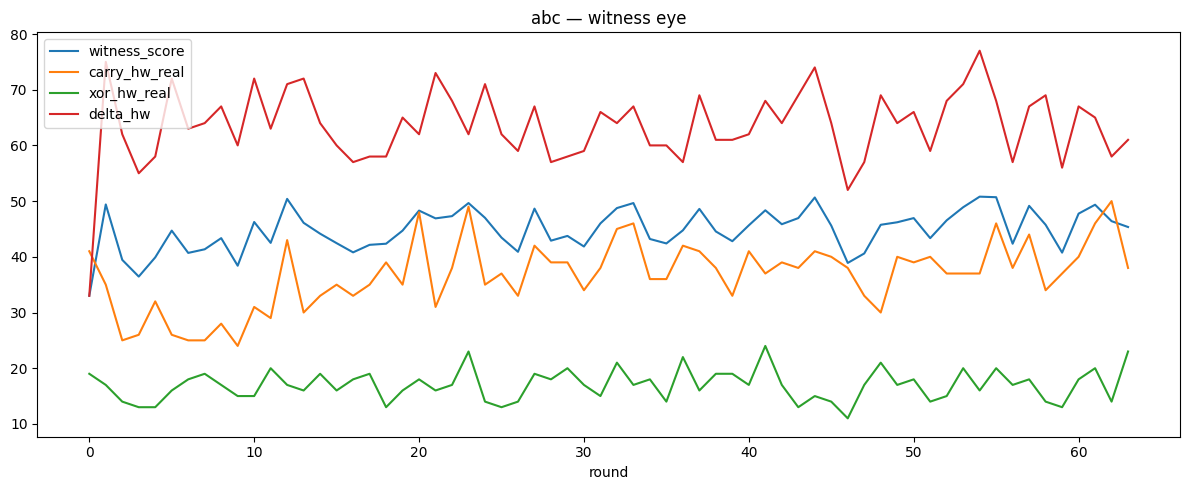

saved: sha_witness_eye_outputs\abc_witness_eye.csv


In [6]:

plot_witness(df_abc, title="abc — witness eye")
csv_path = OUTDIR / "abc_witness_eye.csv"
df_abc.to_csv(csv_path, index=False)
print("saved:", csv_path)



## Compare multiple encodings

This does not assume the encodings are semantically identical.
It only compares how different ingress forms bend the same closure machine.


In [7]:

samples = {
    "text_abc": encode_text("abc"),
    "hex_abc": encode_hex("616263"),
    "bits_abc": encode_bits("011000010110001001100011"),
    "text_phrase": encode_text("ASCII is transfer code between systems."),
    "hex_demo": encode_hex("deadbeefcafebabe0011223344556677"),
}

rows = []
for name, payload in samples.items():
    df, digest = witness_eye(payload)
    rows.append({
        "name": name,
        "digest": digest,
        "mean_witness_score": float(df["witness_score"].mean()),
        "max_witness_score": float(df["witness_score"].max()),
        "mean_delta_hw": float(df["delta_hw"].mean()),
        "mean_carry_hw": float(df["carry_hw_real"].mean()),
        "mean_xor_hw": float(df["xor_hw_real"].mean()),
    })

compare_df = pd.DataFrame(rows).sort_values("mean_witness_score", ascending=False)
compare_df


,name,digest,mean_witness_score,max_witness_score,mean_delta_hw,mean_carry_hw,mean_xor_hw
3,text_phrase,1c7160568119cdf0ce5e3d5d9c55767a9139c85ee1bcb9...,45.057031,54.0,63.781250,37.953125,15.359375
0,text_abc,ba7816bf8f01cfea414140de5dae2223b00361a396177a...,44.820312,50.8,63.500000,36.718750,16.968750
1,hex_abc,ba7816bf8f01cfea414140de5dae2223b00361a396177a...,44.820312,50.8,63.500000,36.718750,16.968750
2,bits_abc,ba7816bf8f01cfea414140de5dae2223b00361a396177a...,44.820312,50.8,63.500000,36.718750,16.968750
4,hex_demo,5067dad8528877131881b67facf122f339a92a0d9c4114...,44.668750,52.1,64.359375,35.484375,16.437500


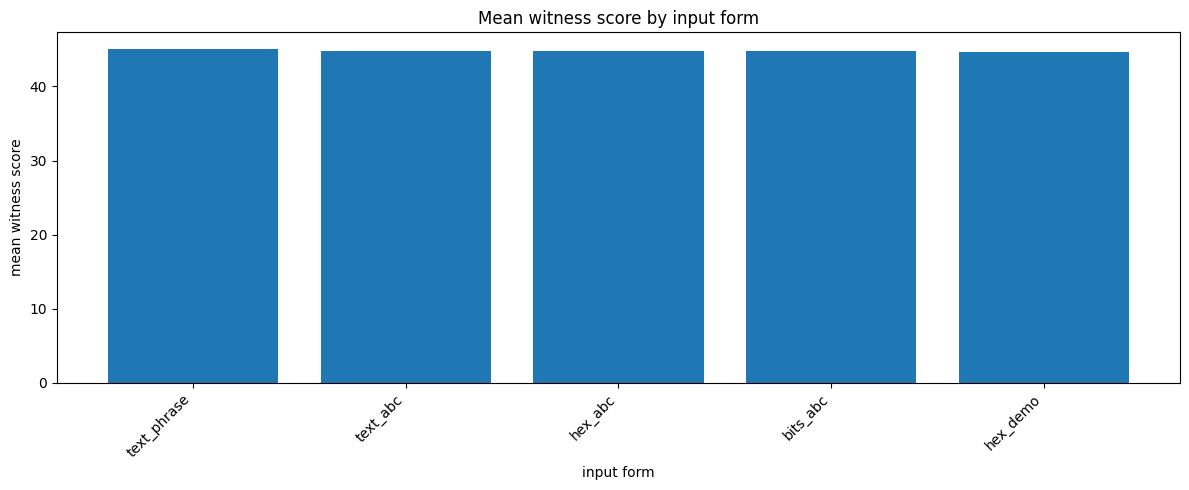

saved: sha_witness_eye_outputs\witness_compare.csv


In [8]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(compare_df["name"], compare_df["mean_witness_score"])
ax.set_title("Mean witness score by input form")
ax.set_xlabel("input form")
ax.set_ylabel("mean witness score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

compare_csv = OUTDIR / "witness_compare.csv"
compare_df.to_csv(compare_csv, index=False)
print("saved:", compare_csv)



## Next move

Compare **witness-eye traces**, not just digests, across:

- same object in different encodings
- mirrored seed layouts
- different probe families
- late-round seam cuts

That is how you go from “the digest is a witness” to “what exactly did SHA witness?”
